# KNN Regression using House Price Dataset

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Load Dataset
Download **train.csv** from Kaggle and place it in the same folder as this notebook.

In [2]:
df = pd.read_csv('/content/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Select Features and Target

In [3]:
features = ['GrLivArea', 'OverallQual', 'GarageCars', 'YearBuilt', 'TotalBsmtSF']

X = df[features]
y = df['SalePrice']

X.head()

,GrLivArea,OverallQual,GarageCars,YearBuilt,TotalBsmtSF
0,1710,7,2,2003,856
1,1262,6,2,1976,1262
2,1786,7,2,2001,920
3,1717,7,3,1915,756
4,2198,8,3,2000,1145


In [6]:
y

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


## Handle Missing Values

In [4]:
X = X.fillna(X.median())
X.isnull().sum()

,0
GrLivArea,0
OverallQual,0
GarageCars,0
YearBuilt,0
TotalBsmtSF,0


## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(1168, 5) (292, 5)


## Feature Scaling

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-0.40709315, -0.82044456, -1.05654384, -0.45546896,  0.57261219],
       [ 0.08317013, -0.08893368,  0.29509165,  0.71860895, -0.59654659],
       [-1.39525026, -0.82044456, -2.40817934, -1.98829291, -0.60335723],
       [ 0.45897505, -0.82044456, -1.05654384, -1.10773447, -0.75092096],
       [ 0.31208684, -0.82044456, -1.05654384, -1.53170705, -0.08120864]])

## Train KNN Regressor

In [17]:
knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor(weights='distance')

## Make Predictions

In [18]:
y_pred = knn.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,154500,140109.877088
1,325000,304489.994658
2,115000,126142.950951
3,159000,187802.448877
4,315500,331234.473203
5,75500,81000.000000
6,311500,177656.427262
7,146000,151371.147823
8,84500,83358.861772
9,135500,99880.844679


## Evaluate Model

In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE          : {mae:.2f}")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R2 Score     : {r2:.4f}")
print(f"Adjusted R2  : {adjusted_r2:.4f}")

MAE          : 19935.30
MSE          : 1008727125.39
RMSE         : 31760.46
R2 Score     : 0.8685
Adjusted R2  : 0.8662


## Visualization: Actual vs Predicted

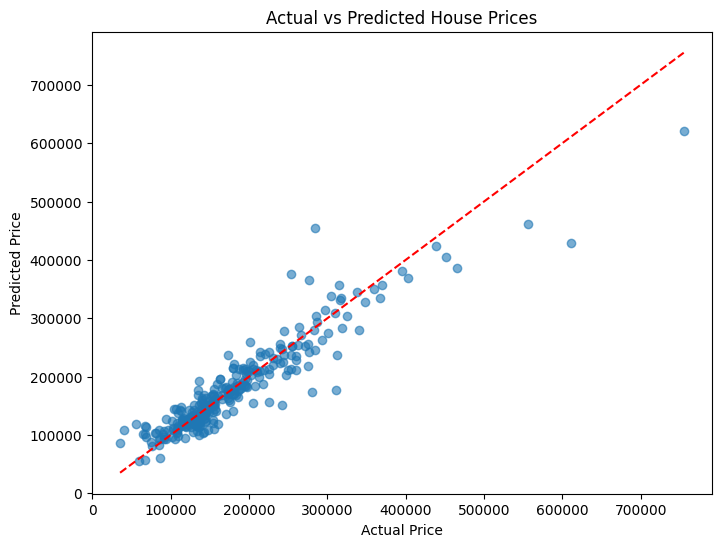

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot([min_price, max_price], [min_price, max_price], 'r--')

plt.show()

## Choose the Best K

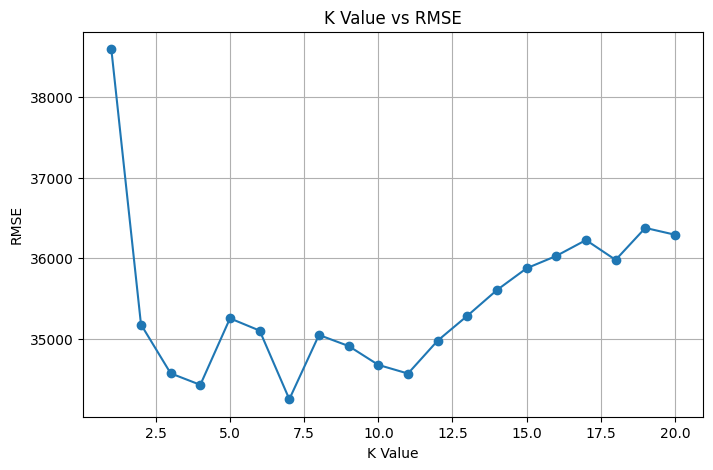

Best K: 7
Minimum RMSE: 34248.28188481349


In [21]:
rmse_values = []

for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    rmse_values.append(np.sqrt(mean_squared_error(y_test, pred)))

plt.figure(figsize=(8,5))
plt.plot(range(1,21), rmse_values, marker='o')
plt.xlabel('K Value')
plt.ylabel('RMSE')
plt.title('K Value vs RMSE')
plt.grid(True)
plt.show()

best_k = np.argmin(rmse_values) + 1
print("Best K:", best_k)
print("Minimum RMSE:", rmse_values[best_k-1])